# Retail Sales & Customer Behavior Analysis

**Author:** Sunanda Guha  
**Tools:** Python, Pandas, Matplotlib, UCI/Kaggle retail data, Tableau-ready exports

## Goal
Analyze real retail transaction data to understand sales performance, customer value, product/category trends, and business opportunities.

## Business Questions
1. What is total revenue, order volume, and average order value?
2. Which products or categories generate the most revenue?
3. What are monthly sales trends?
4. Which customers are high-value?
5. How can customers be segmented for marketing or sales strategy?

## Step 1: Install and import libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files

In [17]:
!pip install pandas openpyxl

## Step 2: Load real data

1. **UCI Online Retail Dataset**  

Upload the CSV or Excel file in the next cell.

Expected columns may include:
- InvoiceNo
- StockCode
- Description
- Quantity
- InvoiceDate
- UnitPrice
- CustomerID
- Country

In [18]:
# Load the file into a DataFrame
df = pd.read_excel('/content/sample_data/Online Retail.xlsx')

# Display the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 3: Inspect the data

In [19]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())
display(df.info())
display(df.describe(include="all"))

Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


None

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


## Step 4: Standardize column names

In [20]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']


## Step 5: Detect important columns

In [21]:
invoice_col = "invoiceno" if "invoiceno" in df.columns else ("invoice_no" if "invoice_no" in df.columns else None)
customer_col = "customerid" if "customerid" in df.columns else ("customer_id" if "customer_id" in df.columns else None)
date_col = "invoicedate" if "invoicedate" in df.columns else ("invoice_date" if "invoice_date" in df.columns else "date" if "date" in df.columns else None)
quantity_col = "quantity" if "quantity" in df.columns else None
price_col = "unitprice" if "unitprice" in df.columns else ("unit_price" if "unit_price" in df.columns else None)
description_col = "description" if "description" in df.columns else None
country_col = "country" if "country" in df.columns else None

print("Detected columns:")
print("Invoice:", invoice_col)
print("Customer:", customer_col)
print("Date:", date_col)
print("Quantity:", quantity_col)
print("Unit Price:", price_col)
print("Description:", description_col)
print("Country:", country_col)

Detected columns:
Invoice: invoiceno
Customer: customerid
Date: invoicedate
Quantity: quantity
Unit Price: unitprice
Description: description
Country: country


## Step 6: Clean and prepare retail data

In [22]:
required = [quantity_col, price_col, date_col]
missing_required = [c for c in required if c is None]

if missing_required:
    raise ValueError("Could not detect required columns. Please check dataset column names.")

clean_df = df.copy()

clean_df[date_col] = pd.to_datetime(clean_df[date_col], errors="coerce")
clean_df[quantity_col] = pd.to_numeric(clean_df[quantity_col], errors="coerce")
clean_df[price_col] = pd.to_numeric(clean_df[price_col], errors="coerce")

clean_df = clean_df.dropna(subset=[date_col, quantity_col, price_col])
clean_df = clean_df[(clean_df[quantity_col] > 0) & (clean_df[price_col] > 0)]
clean_df = clean_df.drop_duplicates()

clean_df["revenue"] = clean_df[quantity_col] * clean_df[price_col]
clean_df["month"] = clean_df[date_col].dt.to_period("M").astype(str)

print("Cleaned shape:", clean_df.shape)
display(clean_df.head())

Cleaned shape: (524878, 10)


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


## Step 7: KPI metrics

In [23]:
total_revenue = clean_df["revenue"].sum()
total_orders = clean_df[invoice_col].nunique() if invoice_col else len(clean_df)
total_customers = clean_df[customer_col].nunique() if customer_col else np.nan
avg_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(avg_order_value, 2))

Total Revenue: 10642110.8
Total Orders: 19960
Total Customers: 4338
Average Order Value: 533.17


## Step 8: Product / category analysis

If your dataset has product descriptions, this analyzes top products by revenue.

In [24]:
if description_col:
    product_summary = (
        clean_df.groupby(description_col)
        .agg(total_revenue=("revenue", "sum"),
             total_quantity=(quantity_col, "sum"),
             order_count=(invoice_col, "nunique") if invoice_col else (description_col, "count"))
        .reset_index()
        .sort_values("total_revenue", ascending=False)
    )
else:
    product_summary = pd.DataFrame()

display(product_summary.head(10))

,description,total_revenue,total_quantity,order_count
1067,DOTCOM POSTAGE,206248.77,706,706
2853,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3844,WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2256
2413,PARTY BUNTING,99445.23,18283,1685
1816,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
2692,POSTAGE,78101.88,3150,1126
2192,Manual,77752.82,6985,290
2741,RABBIT NIGHT LIGHT,66870.03,30739,994


## Step 9: Monthly sales trend

In [25]:
monthly_summary = (
    clean_df.groupby("month")
    .agg(total_revenue=("revenue", "sum"),
         total_quantity=(quantity_col, "sum"),
         order_count=(invoice_col, "nunique") if invoice_col else ("revenue", "count"))
    .reset_index()
)

display(monthly_summary.head())

,month,total_revenue,total_quantity,order_count
0,2010-12,821452.730,358019,1559
1,2011-01,689811.610,387099,1086
2,2011-02,522545.560,282934,1100
3,2011-03,716215.260,376599,1454
4,2011-04,536968.491,307953,1246


## Step 10: Customer segmentation

In [26]:
if customer_col:
    customer_summary = (
        clean_df.groupby(customer_col)
        .agg(total_revenue=("revenue", "sum"),
             order_count=(invoice_col, "nunique") if invoice_col else ("revenue", "count"),
             total_quantity=(quantity_col, "sum"))
        .reset_index()
        .sort_values("total_revenue", ascending=False)
    )

    # Segment customers into value groups
    customer_summary["customer_segment"] = pd.qcut(
        customer_summary["total_revenue"].rank(method="first"),
        q=3,
        labels=["Low Value", "Medium Value", "High Value"]
    )

    display(customer_summary.head(10))
else:
    customer_summary = pd.DataFrame()
    print("Customer column not found. Customer segmentation skipped.")

,customerid,total_revenue,order_count,total_quantity,customer_segment
1689,14646.0,280206.02,73,196915,High Value
4201,18102.0,259657.30,60,64124,High Value
3728,17450.0,194390.79,46,69973,High Value
3008,16446.0,168472.50,2,80997,High Value
1879,14911.0,143711.17,201,80240,High Value
55,12415.0,124914.53,21,77374,High Value
1333,14156.0,117210.08,55,57768,High Value
3771,17511.0,91062.38,31,64549,High Value
2702,16029.0,80850.84,63,40108,High Value
0,12346.0,77183.60,1,74215,High Value


## Step 11: Visualizations

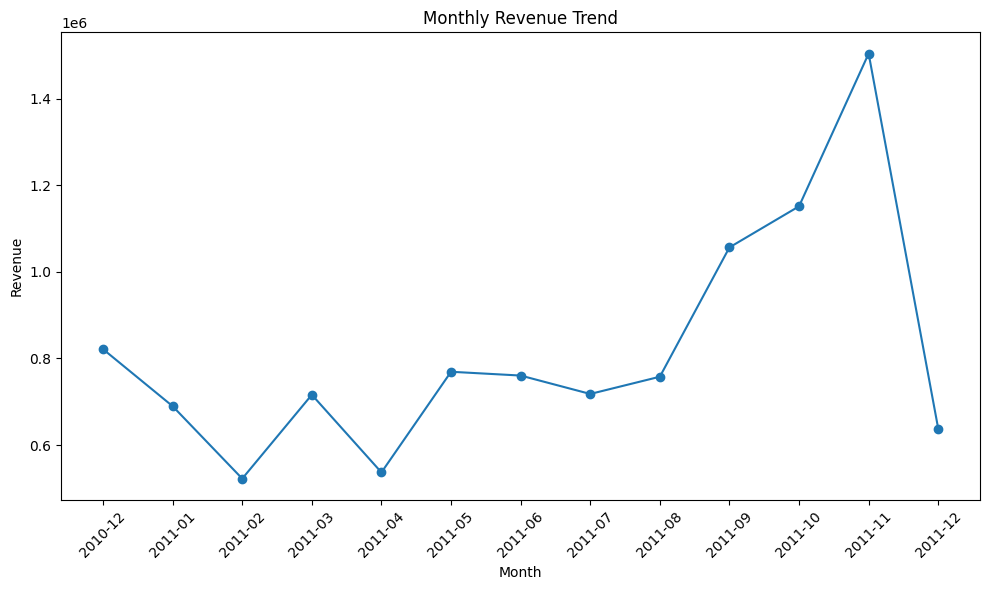

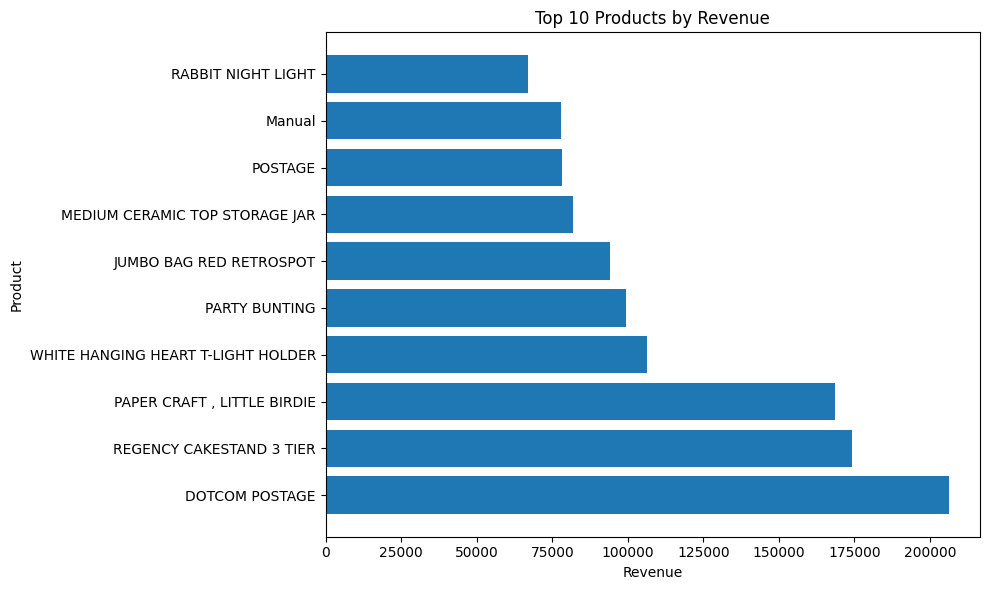

/tmp/ipykernel_2389/1056945050.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_summary = customer_summary.groupby("customer_segment")["total_revenue"].sum().reset_index()


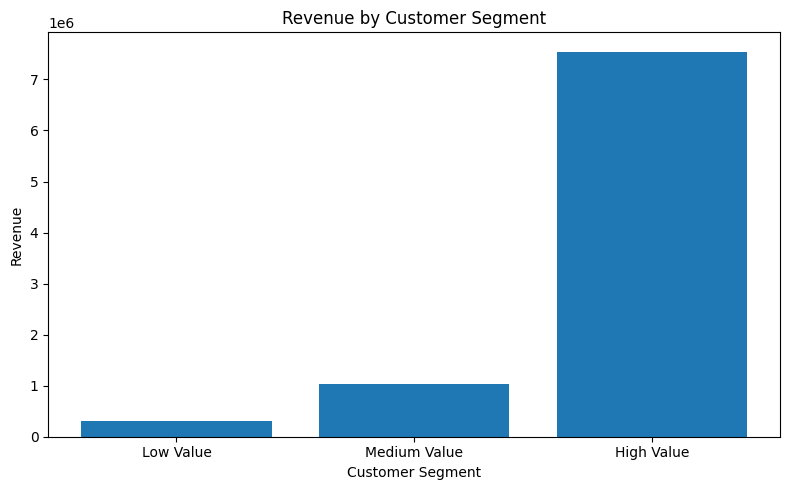

In [27]:
# Monthly revenue trend
plt.figure(figsize=(10, 6))
plt.plot(monthly_summary["month"], monthly_summary["total_revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top products by revenue
if description_col and not product_summary.empty:
    top_products = product_summary.head(10)
    plt.figure(figsize=(10, 6))
    plt.barh(top_products[description_col].astype(str), top_products["total_revenue"])
    plt.title("Top 10 Products by Revenue")
    plt.xlabel("Revenue")
    plt.ylabel("Product")
    plt.tight_layout()
    plt.show()

# Customer segments
if customer_col and not customer_summary.empty:
    seg_summary = customer_summary.groupby("customer_segment")["total_revenue"].sum().reset_index()
    plt.figure(figsize=(8, 5))
    plt.bar(seg_summary["customer_segment"].astype(str), seg_summary["total_revenue"])
    plt.title("Revenue by Customer Segment")
    plt.xlabel("Customer Segment")
    plt.ylabel("Revenue")
    plt.tight_layout()
    plt.show()

## Step 12: Business insights summary

In [28]:
print("BUSINESS INSIGHTS")
print("-----------------")
print(f"1. Total revenue analyzed: {total_revenue:,.2f}")
print(f"2. Total orders analyzed: {total_orders:,}")
print(f"3. Average order value: {avg_order_value:,.2f}")

if description_col and not product_summary.empty:
    top_product = product_summary.iloc[0]
    print(f"4. Top revenue product: {top_product[description_col]} with revenue {top_product['total_revenue']:,.2f}")

if customer_col and not customer_summary.empty:
    top_customer = customer_summary.iloc[0]
    print(f"5. Top customer contributed revenue of {top_customer['total_revenue']:,.2f}")

print("6. Recommendation: Focus marketing and retention efforts on high-value customers and high-revenue products.")

BUSINESS INSIGHTS
-----------------
1. Total revenue analyzed: 10,642,110.80
2. Total orders analyzed: 19,960
3. Average order value: 533.17
4. Top revenue product: DOTCOM POSTAGE with revenue 206,248.77
5. Top customer contributed revenue of 280,206.02
6. Recommendation: Focus marketing and retention efforts on high-value customers and high-revenue products.


## Step 13: Export files for Tableau / GitHub

In [29]:
clean_df.to_csv("cleaned_retail_data.csv", index=False)
monthly_summary.to_csv("retail_monthly_summary.csv", index=False)

if description_col and not product_summary.empty:
    product_summary.to_csv("retail_product_summary.csv", index=False)

if customer_col and not customer_summary.empty:
    customer_summary.to_csv("retail_customer_summary.csv", index=False)

print("Exported Tableau-ready CSV files.")

files.download("cleaned_retail_data.csv")
files.download("retail_monthly_summary.csv")

if description_col and not product_summary.empty:
    files.download("retail_product_summary.csv")

if customer_col and not customer_summary.empty:
    files.download("retail_customer_summary.csv")

Exported Tableau-ready CSV files.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>